In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import os

os.chdir(r"C:\Users\ElMorado\OneDrive\Escritorio\LIBROS Y CURSOS\CURSO EBAC\Datasets")

from sklearn.cluster import KMeans


In [10]:
data = pd.read_csv('iris.csv')
data

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [12]:
df = data.drop(columns = ['variety'])
df

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
fields = df.values
fields

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [18]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
wcss = []

for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = 'k-means++', random_state = 2)
    kmeans.fit(fields)

    wcss.append(kmeans.inertia_)


Text(0, 0.5, 'WCSS')

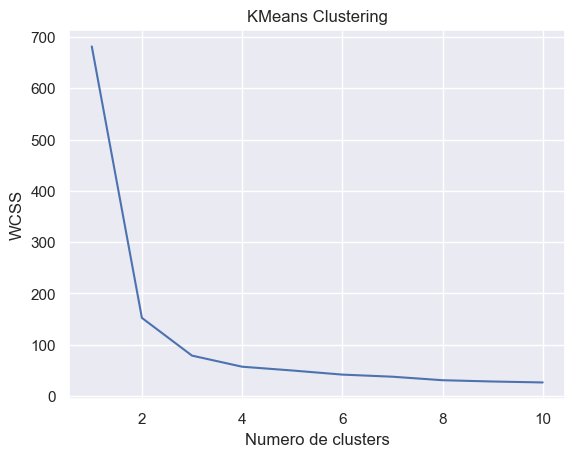

In [22]:
#Graficacion del codo de jambus
sb.set()
plt.plot(range(1,11), wcss) # el range son las x y wcss los valores de y
plt.title("KMeans Clustering")
plt.xlabel("Numero de clusters")
plt.ylabel("WCSS")

# el numero optimo de clusters segun la fradica de codo son 3

In [56]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


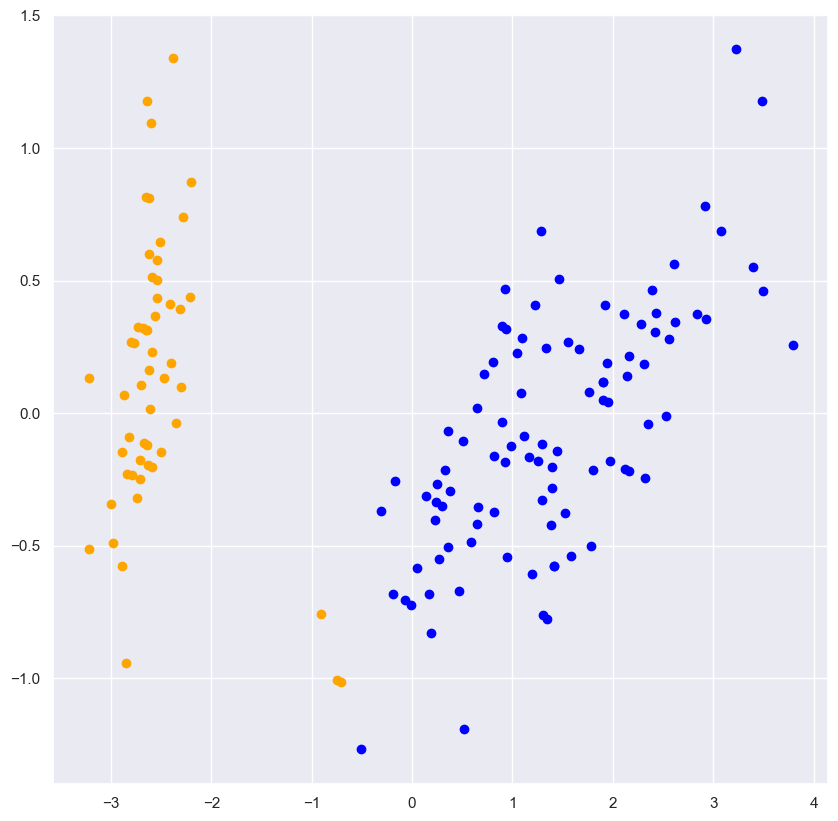

In [88]:
plt.figure(figsize = (10,10))
plt.scatter(fields[cluster_values == 0,0],fields[cluster_values==0,1], c='blue',label='Cluster 1')
plt.scatter(fields[cluster_values == 1,0],fields[cluster_values==1,1], c='orange',label='Cluster 2')
plt.scatter(fields[cluster_values == 2,0],fields[cluster_values==2,1], c='green',label='Cluster 3')

plt.savefig("puntos kmeans.png")

In [60]:
# Criterio de silueta "Silhouette"
# se medira el grado de similitud de cada punto en cada grupo
from sklearn import datasets
from sklearn.metrics import silhouette_score

In [62]:
X = fields
for j in range(2,12): 
    kmeans = KMeans(n_clusters=j, random_state=42)
    kmeans.fit_predict(X)
    #calculamos el score de silueta
    score = silhouette_score(X,kmeans.labels_, metric='euclidean')
    print("Score silhouette:", 'k = ',j,':', score)

# el numero optimo de clusters es 2

Score silhouette: k =  2 : 0.7056703225102108
Score silhouette: k =  3 : 0.597676421954799
Score silhouette: k =  4 : 0.5577409232246783
Score silhouette: k =  5 : 0.5100407194899202
Score silhouette: k =  6 : 0.40319738737442673
Score silhouette: k =  7 : 0.3868263997713608
Score silhouette: k =  8 : 0.4407603324965402
Score silhouette: k =  9 : 0.40201438763663605
Score silhouette: k =  10 : 0.4158865801753246
Score silhouette: k =  11 : 0.3994325519305235


In [68]:
# PCA = Algoritmo de componentes principales
# algoritmo pca para reducir la dimension de 4 columns a 2
from sklearn import decomposition
pca = decomposition.PCA(n_components=2)
pca.fit(fields)
fields = pca.transform(fields)
fields

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [96]:
# repetir el calculo de las distancias de cada punto con cada centroide

wcss2 = []

for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = 'k-means++', random_state = 2)
    kmeans.fit(fields)

    wcss2.append(kmeans.inertia_)

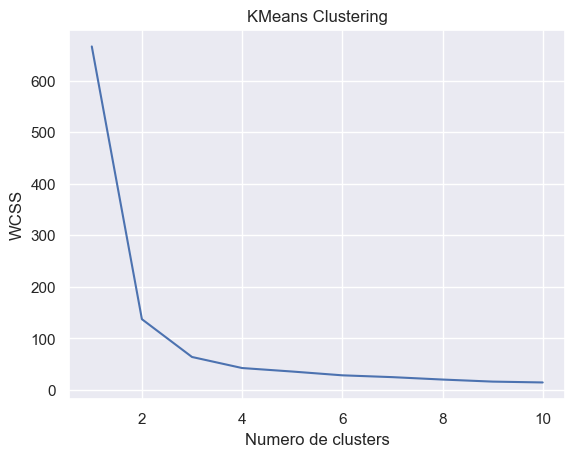

In [97]:
#Graficacion del codo de jambus
sb.set()
plt.plot(range(1,11), wcss2) # el range son las x y wcss los valores de y
plt.title("KMeans Clustering")
plt.xlabel("Numero de clusters")
plt.ylabel("WCSS")

plt.savefig("codo pca.png")

In [76]:
# se vuelve a hacer la prediccion de cada grupo
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


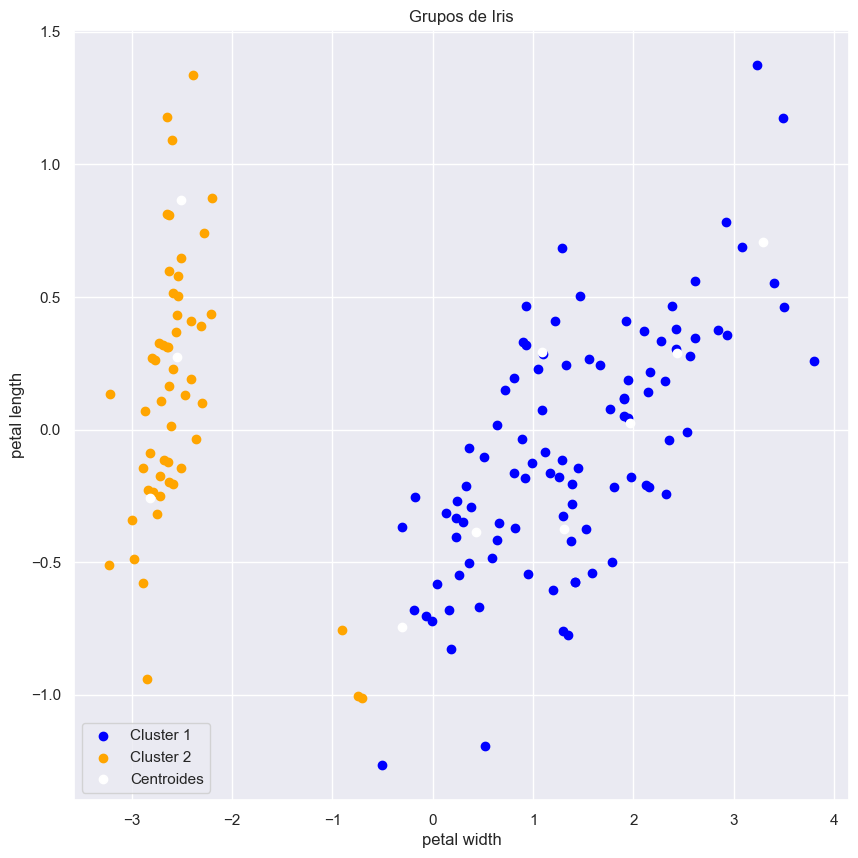

In [100]:
plt.figure(figsize = (10,10))
plt.scatter(fields[cluster_values == 0,0],fields[cluster_values==0,1], c='blue', label='Cluster 1')
plt.scatter(fields[cluster_values == 1,0],fields[cluster_values==1,1], c='orange', label='Cluster 2')


plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c = "white", label = "Centroides")

plt.legend()
plt.title("Grupos de Iris")
plt.xlabel("petal width")
plt.ylabel("petal length")

plt.savefig("puntos pca.png")
